In [76]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

from scipy.optimize import curve_fit

import dexplore as dx 
import xarray as xr
import os
import sys
import glob
import re

sys.path.append(os.path.abspath("steele-lab-analysis-functions"))
import analysis_functions.core as af
from analysis_functions.users.pacome._format_data_xarray import format_data_xarray

from cavity_analysis import cavity_analysis
from cavity_theory import cavity_modes

model = af.ComplexCircle()

In [7]:
dx.refresh_bokeh()

Loading BokehJS ...

In [8]:
base_folder = '/home/jovyan/steelelab/measurement_data/4KDIY/Pacome/SA_RBW'
#base_folder = '/home/jovyan/BACKUP/Pacome/SA_RBW'

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'rbw']


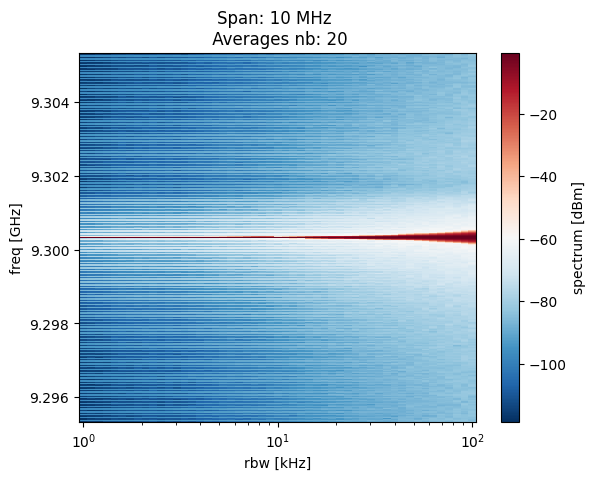

In [11]:
file_folder = '2026-06-24_12.27.24_0001_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
#dx.interactive_linecut_and_colormap(data, initial_var=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'rbw':['rbw', 'kHz', 1e3]}

data_noise = format_data_xarray(data, tool='SA', translator=translator)
data_noise.spect.plot(cmap='RdBu_r')
plt.xscale('log')
plt.title('Span: 10 MHz \n Averages nb: 20')
plt.show()

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'rbw']


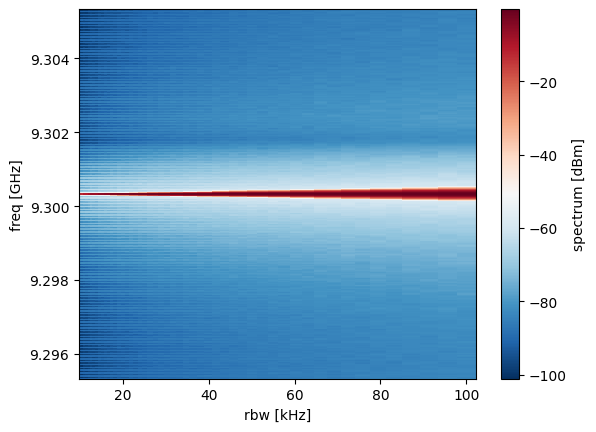

In [12]:
file_folder = '2026-06-24_13.36.46_0002_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
#dx.interactive_linecut_and_colormap(data, initial_var=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'rbw':['rbw', 'kHz', 1e3]}

data_noise = format_data_xarray(data, tool='SA', translator=translator)
data_noise.spect.plot(cmap='RdBu_r')

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'rbw']


[]

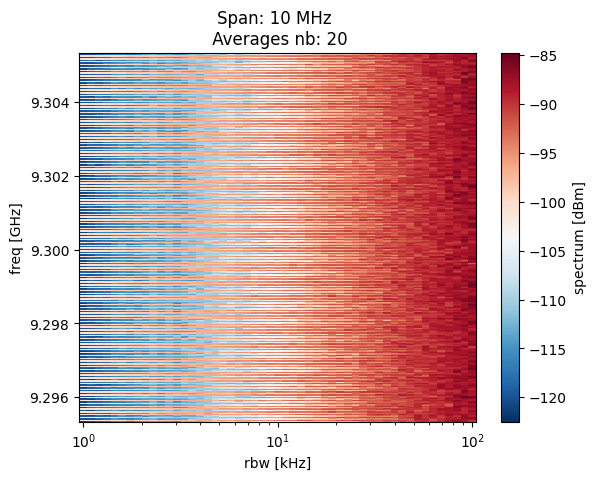

In [14]:
file_folder = '2026-06-24_15.34.40_0004_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
#dx.interactive_linecut_and_colormap(data, initial_var=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'rbw':['rbw', 'kHz', 1e3]}

data_noise = format_data_xarray(data, tool='SA', translator=translator)
data_noise.spect.plot(cmap='RdBu_r')
plt.xscale('log')
plt.title('Span: 10 MHz \n Averages nb: 20')
plt.plot()

Dropping dummy coordinate/dimension 0: "span"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']


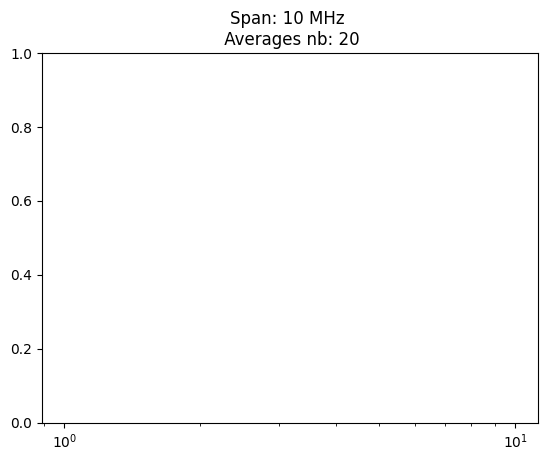

In [19]:
file_folder = '2026-06-24_16.15.32_0005_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
#dx.interactive_linecut_and_colormap(data, initial_var=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'rbw':['rbw', 'kHz', 1e3]}

data_noise = format_data_xarray(data, tool='SA', translator=translator)
#data_noise.spect.plot(cmap='RdBu_r')
plt.xscale('log')
plt.title('Span: 10 MHz \n Averages nb: 20')
plt.show()

# dBc/HZ for different RBW

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'rbw']


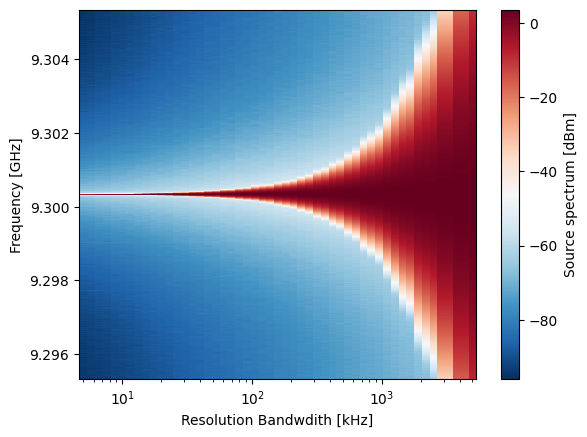

In [58]:
file_folder = '2026-06-29_14.02.27_0007_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
#dx.interactive_linecut_and_colormap(data, initial_var=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'rbw':['rbw', 'kHz', 1e3]}

data_source = format_data_xarray(data, tool='SA', translator=translator)
plt.figure()
plt.pcolormesh(data_source.rbw.values, data_source.freq.values, data_source.spect.values,
              cmap = 'RdBu_r')
plt.colorbar(label='Source spectrum [dBm]')
plt.xscale('log')
plt.xlabel('Resolution Bandwdith [kHz]')
plt.ylabel('Frequency [GHz]')
plt.show()

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'rbw']


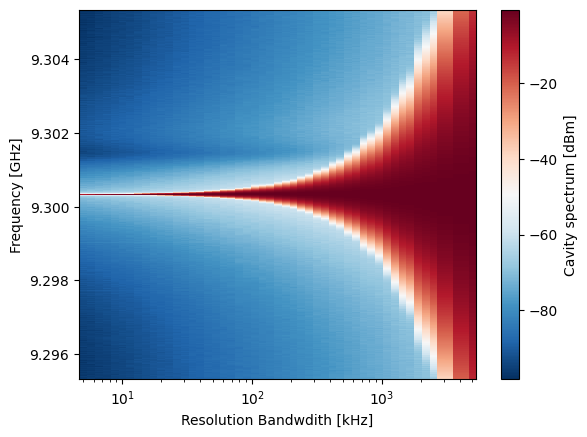

In [59]:
file_folder = '2026-06-29_12.23.07_0006_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
#dx.interactive_linecut_and_colormap(data, initial_var=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'rbw':['rbw', 'kHz', 1e3]}

data_cavity = format_data_xarray(data, tool='SA', translator=translator)
plt.figure()
plt.pcolormesh(data_cavity.rbw.values, data_cavity.freq.values, data_cavity.spect.values,
              cmap = 'RdBu_r')
plt.colorbar(label='Cavity spectrum [dBm]')
plt.xscale('log')
plt.xlabel('Resolution Bandwdith [kHz]')
plt.ylabel('Frequency [GHz]')
plt.show()

In [37]:
fc = 9.30154207e+09
fm = 1.21e+06 + 881

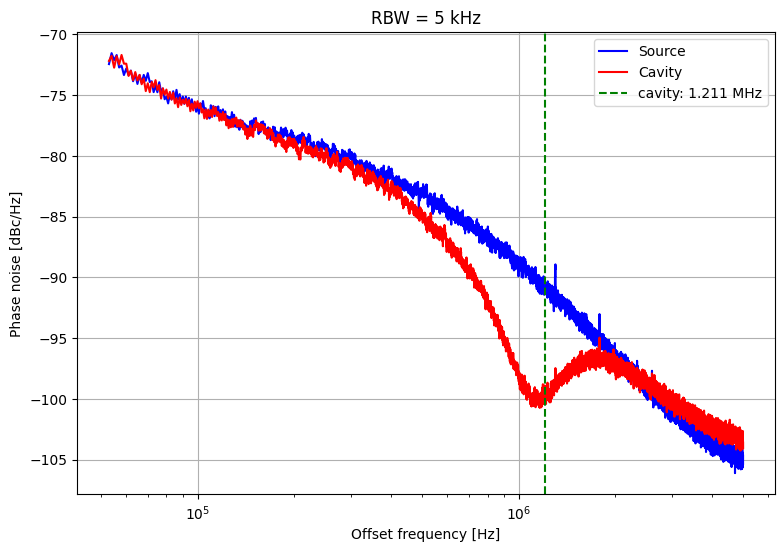

In [66]:
bw_idx = 0

_source = data_source.isel(rbw=bw_idx)
window = slice(f0 + 5e-5, _source.freq.values[-1])
w_source = data_source.isel(rbw=bw_idx).sel(freq = window)
_cavity = data_cavity.isel(rbw=bw_idx)
w_cavity = data_cavity.isel(rbw=bw_idx).sel(freq = window)

f0 = _source.freq.values[np.argmax(_source.spect.values)]

dBmmax_source = np.max(_source.spect.values)
dBmmax_cavity = np.max(_cavity.spect.values)
bandwidth = _source.rbw.values

dBc_source = np.array(w_source.spect.values) - dBmmax_source - 10*np.log10(bandwidth)
dBc_cavity = np.array(w_cavity.spect.values) - dBmmax_cavity - 10*np.log10(bandwidth)

plt.figure(figsize=(9,6))
plt.semilogx((np.array(w_source.freq.values) - f0)*1e+09, dBc_source, color='blue', label='Source')
plt.semilogx((np.array(w_cavity.freq.values) - f0)*1e+09, dBc_cavity, color='red', label='Cavity')
plt.axvline(fm, color='green', linestyle='--', label=f'cavity: {fm*1e-6:.3f} MHz')

plt.xlabel('Offset frequency [Hz]')
plt.ylabel('Phase noise [dBc/Hz]')
plt.legend()
plt.title(f'RBW = {_source.rbw.values:.0f} kHz')
plt.grid(True)
plt.show()

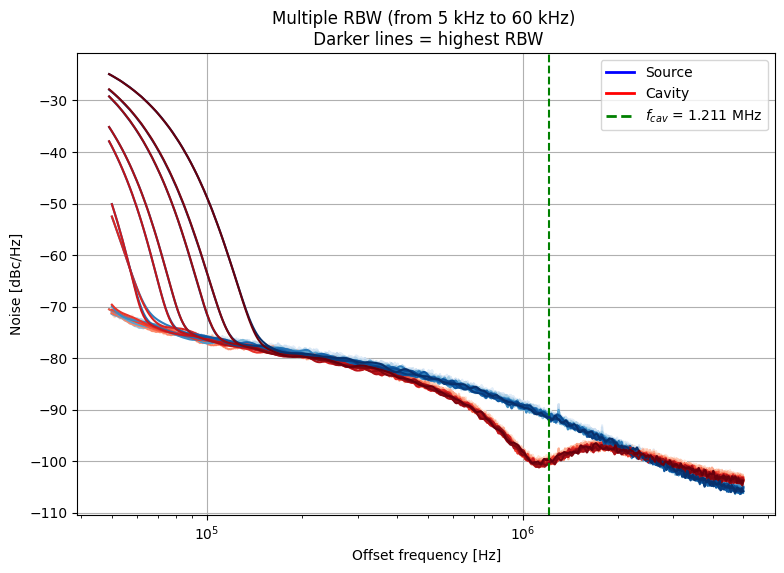

In [94]:
bw_idx = 0
n = 19
colors_b = plt.cm.Blues(np.linspace(0.1, 1, n))
colors_r = plt.cm.Reds(np.linspace(0.1, 1, n))

plt.figure(figsize=(9,6))
for bw_idx in range(n):
    _source = data_source.isel(rbw=bw_idx)
    window = slice(f0 + 5e-5, _source.freq.values[-1])
    w_source = data_source.isel(rbw=bw_idx).sel(freq = window)
    _cavity = data_cavity.isel(rbw=bw_idx)
    w_cavity = data_cavity.isel(rbw=bw_idx).sel(freq = window)

    f0 = _source.freq.values[np.argmax(_source.spect.values)]

    dBmmax_source = np.max(_source.spect.values)
    dBmmax_cavity = np.max(_cavity.spect.values)
    bandwidth = _source.rbw.values

    dBc_source = np.array(w_source.spect.values) - dBmmax_source - 10*np.log10(bandwidth)
    dBc_cavity = np.array(w_cavity.spect.values) - dBmmax_cavity - 10*np.log10(bandwidth)

    plt.semilogx((np.array(w_source.freq.values) - f0)*1e+09, dBc_source, color = colors_b[bw_idx])
    plt.semilogx((np.array(w_cavity.freq.values) - f0)*1e+09, dBc_cavity, color = colors_r[bw_idx])
plt.axvline(fm, color='green', linestyle='--', label=f'cavity: {fm*1e-6:.3f} MHz')

legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='Source'),
    Line2D([0], [0], color='red', lw=2, label='Cavity'),
    Line2D([0], [0], color='green', linestyle='--', lw=2, label=f'$f_{{cav}}$ = {fm*1e-6:.3f} MHz')
]

plt.xlabel('Offset frequency [Hz]')
plt.ylabel('Noise [dBc/Hz]')
plt.legend(handles=legend_elements)
plt.title(f'Multiple RBW (from 5 kHz to 60 kHz) \n Darker lines = highest RBW')
plt.grid(True)
plt.show()